In [83]:
!pip3 install whois

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 61 kB 585 kB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [86]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tldextract import extract
import re

#### data collection

In [87]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json() 
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")
        
        return []

In [88]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

with open("crypto_datasets.json", "w") as file:
    json.dump(datasets_raw, file)

In [89]:
datasets_df = pd.read_json("crypto_datasets.json")

#### eda

In [90]:
# view the first few rows
datasets_df.head()

,name,url,label,label_no
0,doge20,doge20.pages.dev,scam,1
1,snap-dioneprotocol,snap-dioneprotocol.pages.dev,scam,1
2,bitcminetirix,bitcminetirix.online,scam,1
3,claim-xrp,claim-xrp.xyz,scam,1
4,madpack,madpack.site,scam,1


In [91]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199287 entries, 0 to 199286
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   name      199287 non-null  object
 1   url       199287 non-null  object
 2   label     199287 non-null  object
 3   label_no  199287 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 6.1+ MB
None


In [92]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     198096
legit      1191
Name: count, dtype: int64

In [93]:
# Summary statistics for numerical columns (if any)
print(datasets_df.describe())

            label_no
count  199287.000000
mean        0.994024
std         0.077075
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000


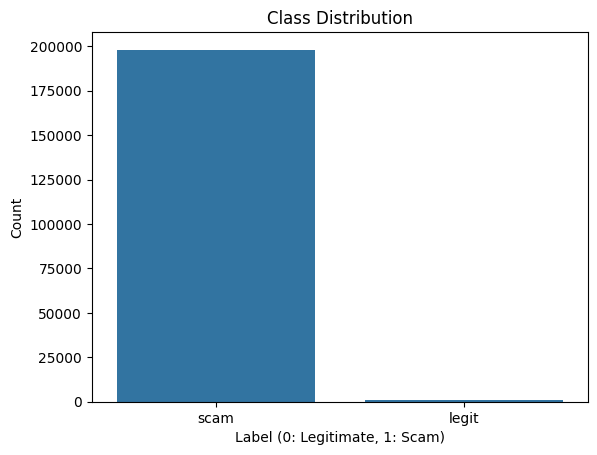

In [94]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

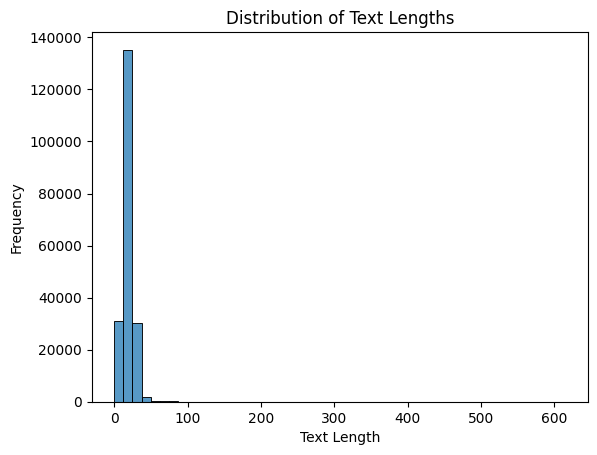

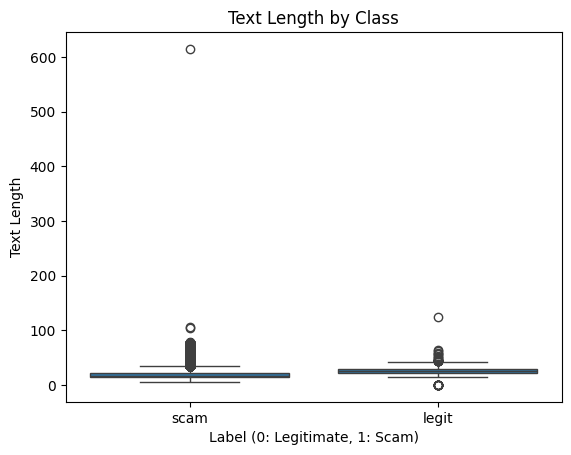

In [95]:
# add a column for text length
datasets_df["text_length"] = datasets_df["url"].apply(len)

# plot the distribution of text lengths
sns.histplot(datasets_df["text_length"], bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# compare text lengths for scam vs. legitimate links
sns.boxplot(x="label", y="text_length", data=datasets_df)
plt.title("Text Length by Class")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Text Length")
plt.show()

Unique domains: 158519
Top TLDs: tld
com        55764
io         17197
dev        15053
xyz        14243
app        13318
net        12168
org         8152
top         4805
pro         3734
network     3569
Name: count, dtype: int64


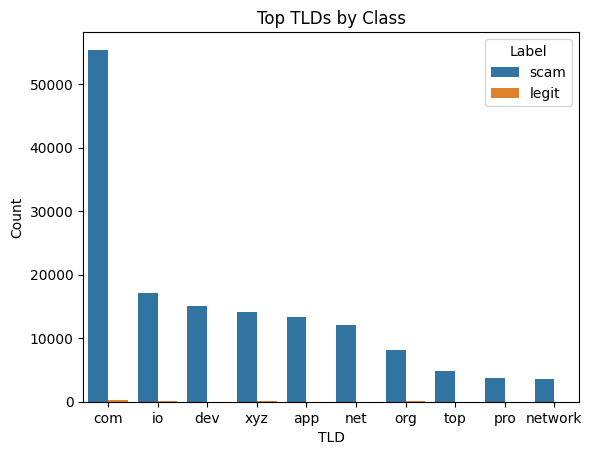

In [96]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: extract(x).registered_domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

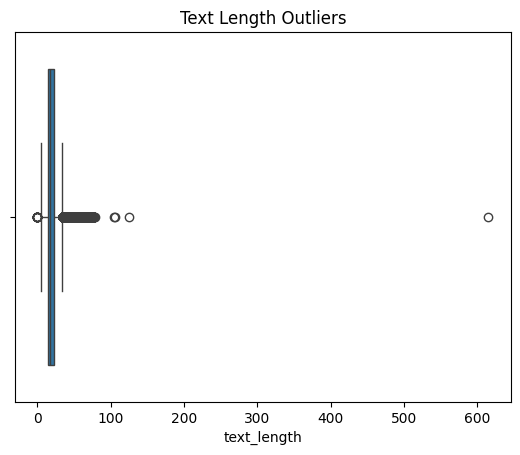

In [97]:
# boxplot for text length
sns.boxplot(x=datasets_df["text_length"])
plt.title("Text Length Outliers")
plt.show()

#### preprocessing

In [99]:
# function to clean text
def clean_text(text):
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert to lowercase
    text = text.lower()
    return text

# apply cleaning to the text column        
datasets_df["cleaned_url"] = datasets_df["url"].apply(clean_text)

# inspect the cleaned text
print(datasets_df["cleaned_url"].head())

0                 dogepagesdev
1    snapdioneprotocolpagesdev
2          bitcminetirixonline
3                  claimxrpxyz
4                  madpacksite
Name: cleaned_url, dtype: object


In [100]:
datasets_df

,name,url,label,label_no,text_length,domain,tld,cleaned_url
0,doge20,doge20.pages.dev,scam,1,16,pages.dev,dev,dogepagesdev
1,snap-dioneprotocol,snap-dioneprotocol.pages.dev,scam,1,28,pages.dev,dev,snapdioneprotocolpagesdev
2,bitcminetirix,bitcminetirix.online,scam,1,20,bitcminetirix.online,online,bitcminetirixonline
3,claim-xrp,claim-xrp.xyz,scam,1,13,claim-xrp.xyz,xyz,claimxrpxyz
4,madpack,madpack.site,scam,1,12,madpack.site,site,madpacksite
...,...,...,...,...,...,...,...,...
199282,solana-ecosystem,solana-ecosystem.pages.dev,scam,1,26,pages.dev,dev,solanaecosystempagesdev
199283,app-beoble,app-beoble.com,scam,1,14,app-beoble.com,com,appbeoblecom
199284,revshares-dashboard,revshares-dashboard.pages.dev,scam,1,29,pages.dev,dev,revsharesdashboardpagesdev
199285,taobridge,taobridge.org,scam,1,13,taobridge.org,org,taobridgeorg
